Importing Libs

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import  train_test_split

Read Data

In [12]:
df=pd.read_csv(r'D:\vscode\retail_kaggle\retail_sales_dataset.csv')

Head of data

In [13]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Checking Null Values

In [14]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Pairplot

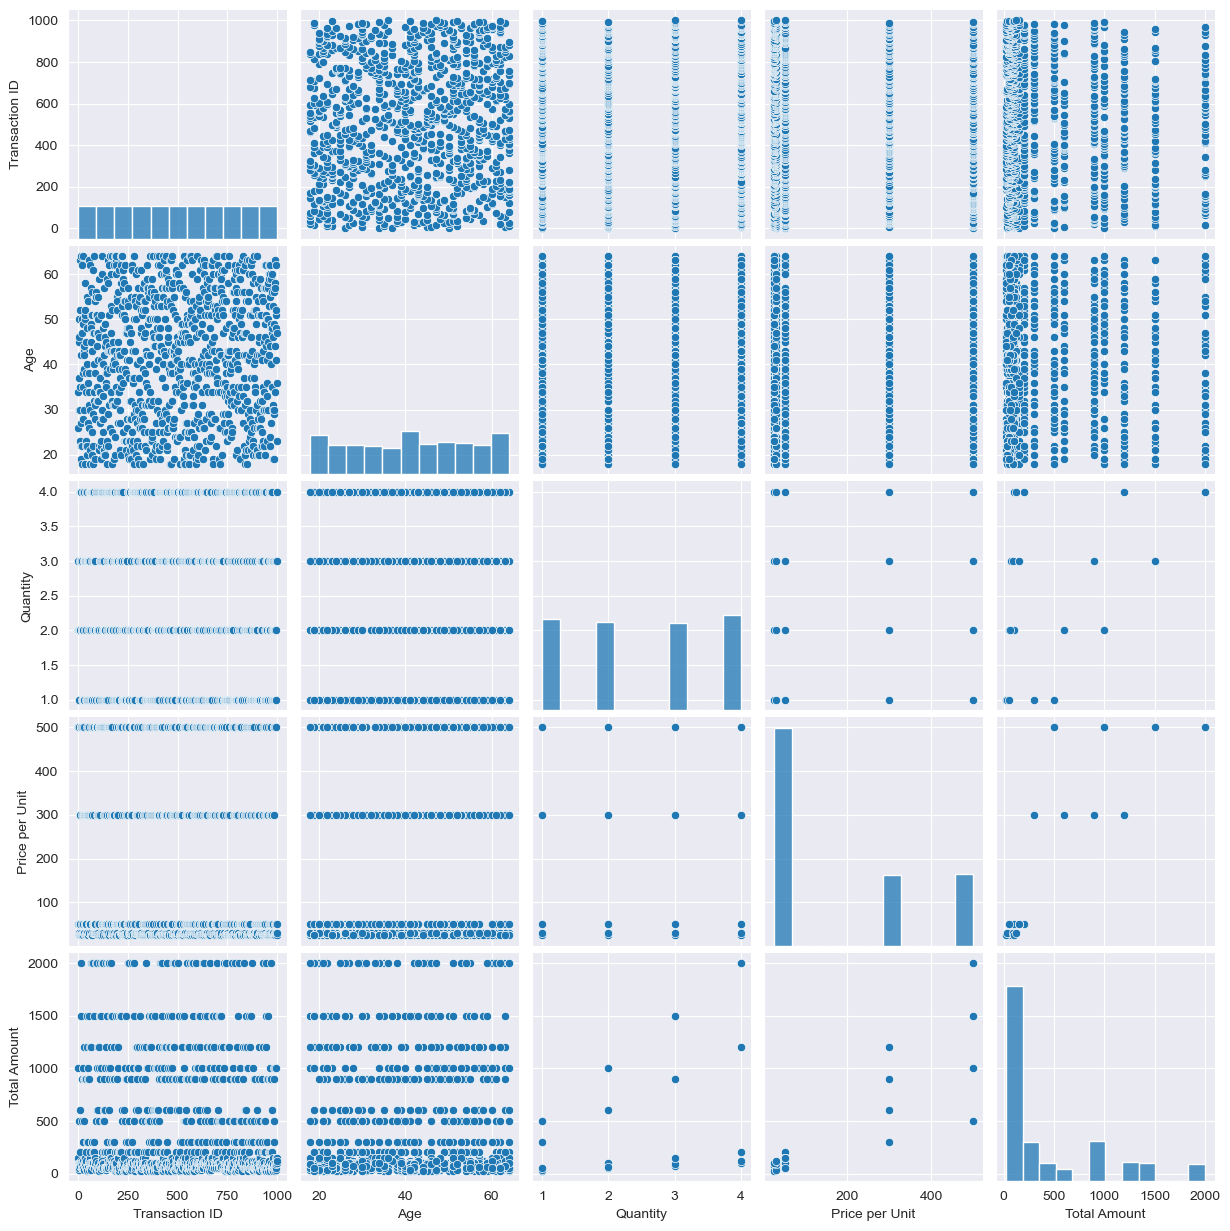

In [15]:
sns.pairplot(data=df)

In [17]:
df['Date']=pd.to_datetime(df['Date'])

AGE GRAPHS

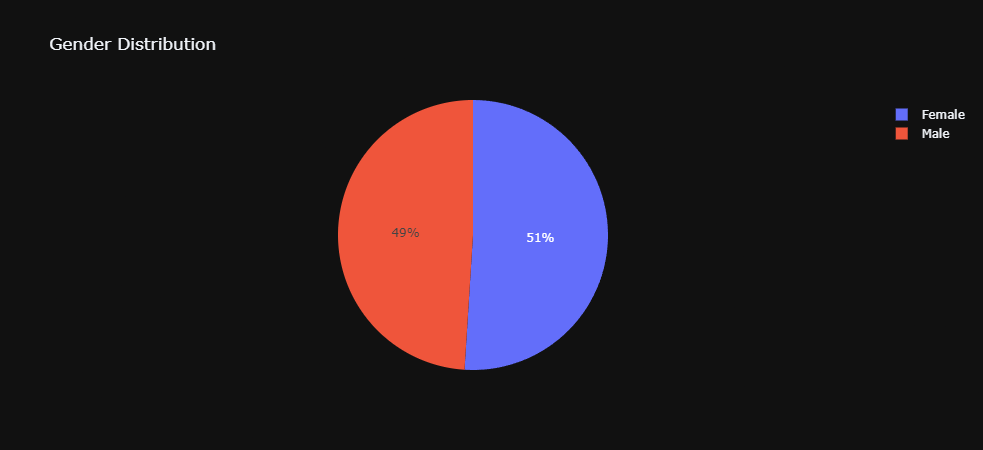

In [19]:
#Pie Chart
#Gender Distribution
df1 = df['Gender']
fig = px.pie(df1,
             names='Gender',
             title='Gender Distribution')
fig.show()

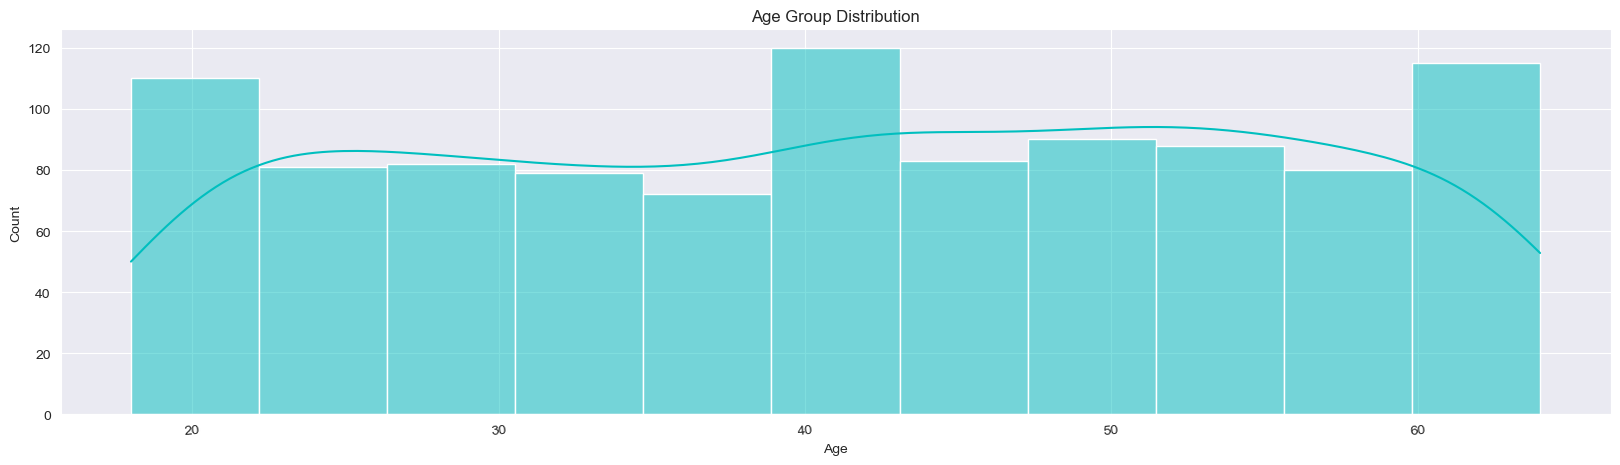

In [32]:
#Histogram Plot
#Age Group Distribution
plt.figure(figsize=(20,5))
sns.histplot(data=df,
             x=df['Age'].sort_values(),
             kde=True,
             color='c')
plt.title('Age Group Distribution')
plt.xticks(rotation=5)
plt.show()

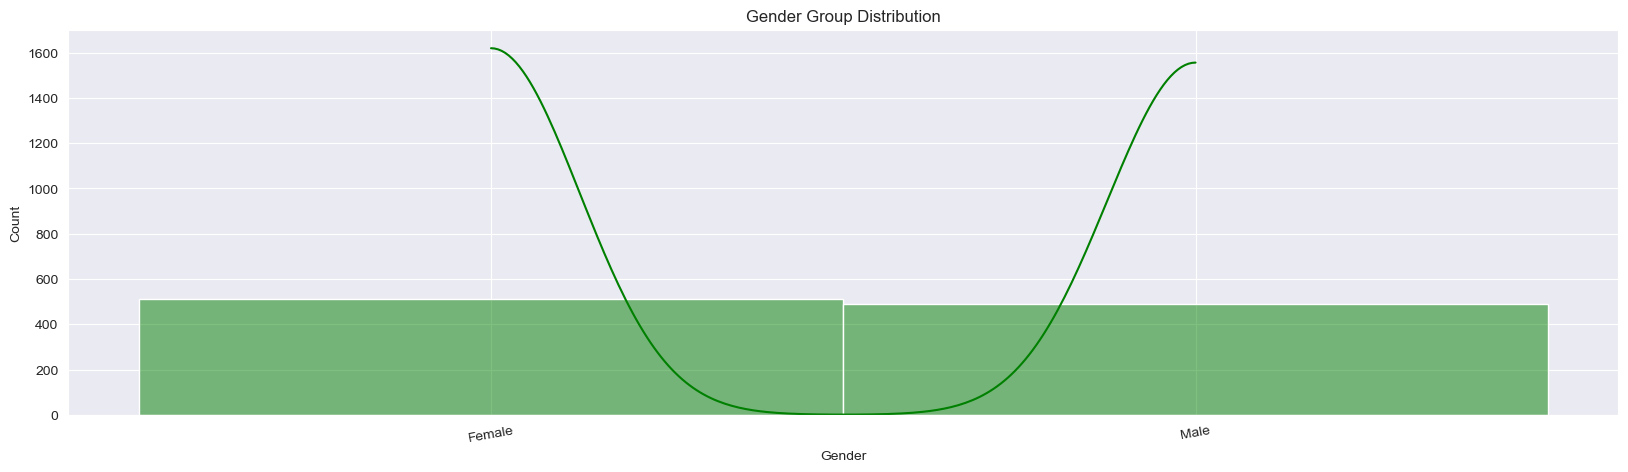

In [33]:
#Hist plot
#Gender Group Distribution
plt.figure(figsize=(20,5))
sns.histplot(data=df,
             x=df['Gender'].sort_values(),
             kde=True,
             color='g')
plt.title('Gender Group Distribution')
plt.xticks(rotation=10)
plt.show()

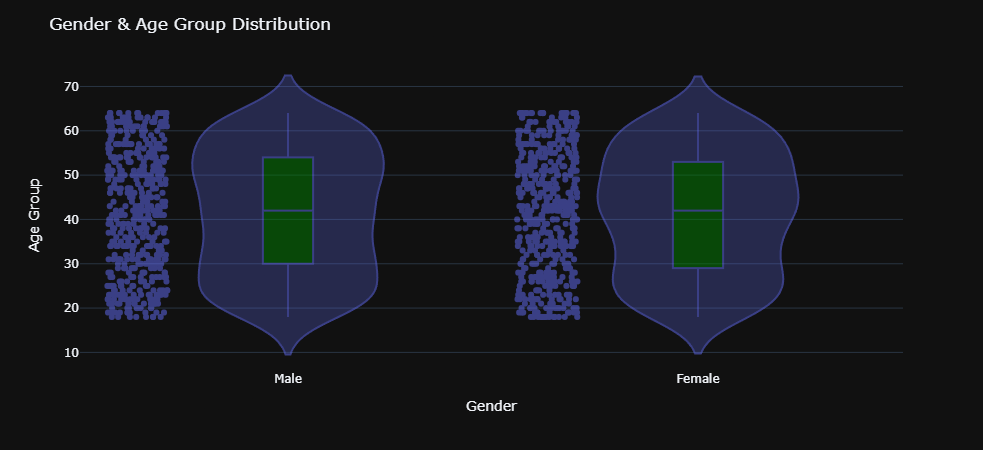

In [34]:
#Violin plot
#Gender & Age Group Distribution
plot = px.violin(x=df['Gender'],
                 y=df['Age'],
                 box=True,
                 points='all')
plot.update_traces(
    box_fillcolor='green',
    opacity=0.5
)
plot.update_layout(
    title='Gender & Age Group Distribution',
    xaxis_title='Gender',
    yaxis_title='Age Group'
)

plot.show()

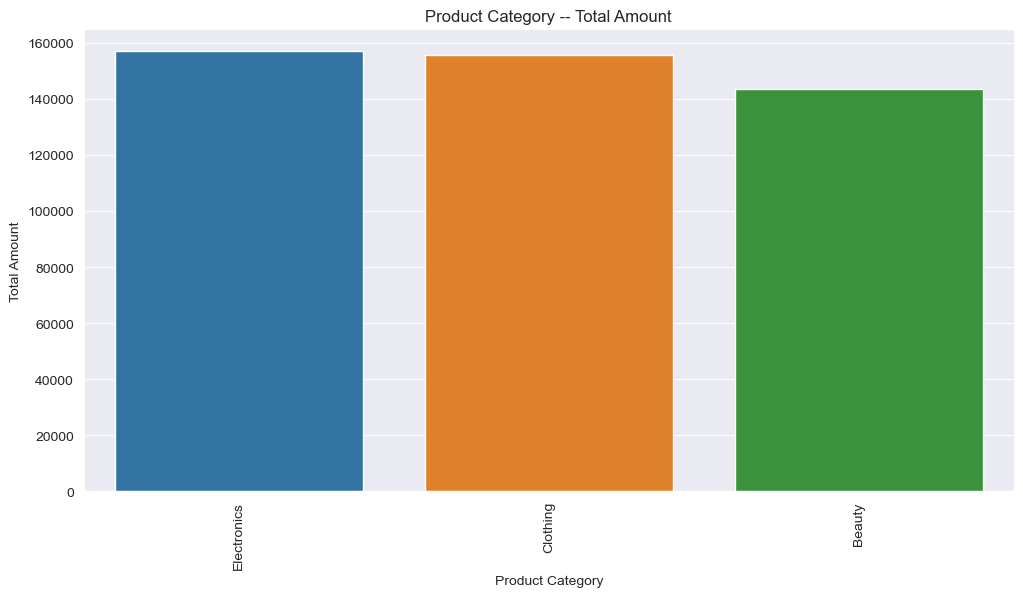

In [42]:
#Bar Plot
#Gold_Item_net_wt_sum
Gold_item_net_wt = df.groupby('Product Category')['Total Amount'].sum().nlargest(40)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=Gold_item_net_wt.index,
    y=Gold_item_net_wt.values)
plt.xticks(rotation=90)
plt.title("Product Category -- Total Amount")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.show()

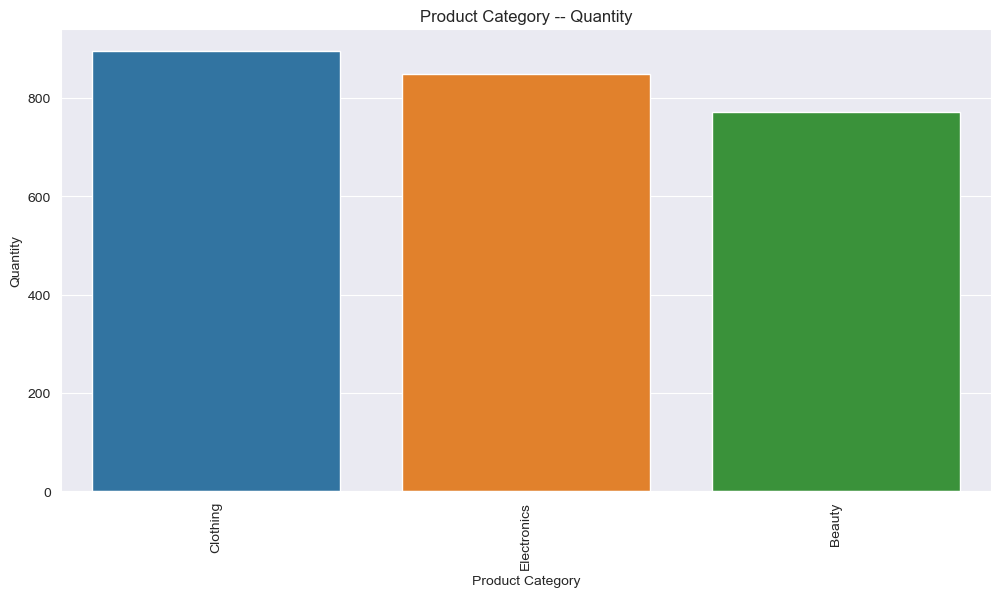

In [44]:
#Bar Plot
#Gold_Item_net_wt_sum
Gold_item_net_wt = df.groupby('Product Category')['Quantity'].sum().nlargest(40)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=Gold_item_net_wt.index,
    y=Gold_item_net_wt.values)
plt.xticks(rotation=90)
plt.title("Product Category -- Quantity")
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.show()

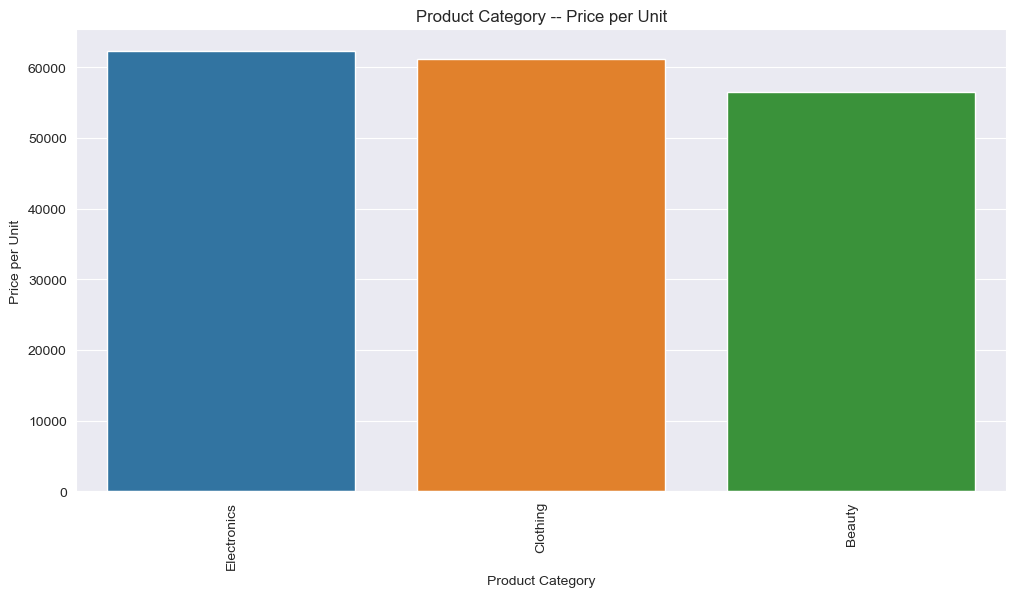

In [45]:
#Bar Plot
#Gold_Item_net_wt_sum
Gold_item_net_wt = df.groupby('Product Category')['Price per Unit'].sum().nlargest(40)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=Gold_item_net_wt.index,
    y=Gold_item_net_wt.values)
plt.xticks(rotation=90)
plt.title("Product Category -- Price per Unit")
plt.xlabel("Product Category")
plt.ylabel("Price per Unit")
plt.show()

Time Series Data

<function matplotlib.pyplot.show(close=None, block=None)>

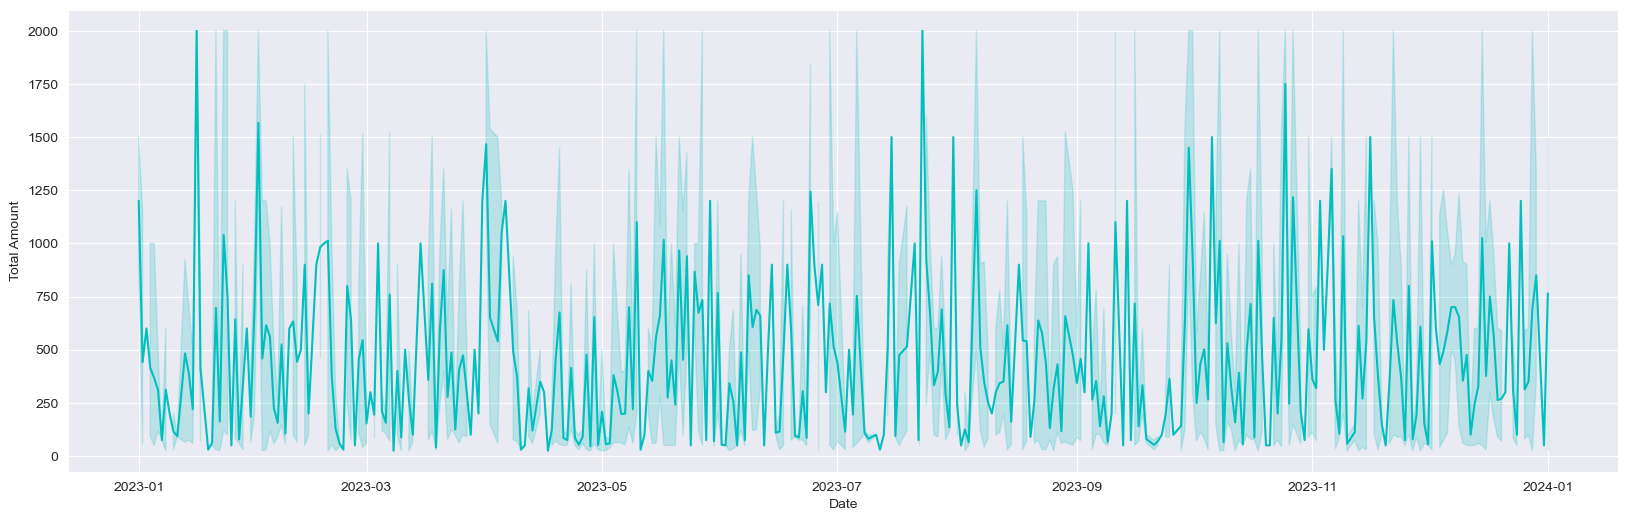

In [46]:
plt.figure(figsize=(20,6))
sns.lineplot(data=df,x=df['Date'],y=df['Total Amount'],color='c')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

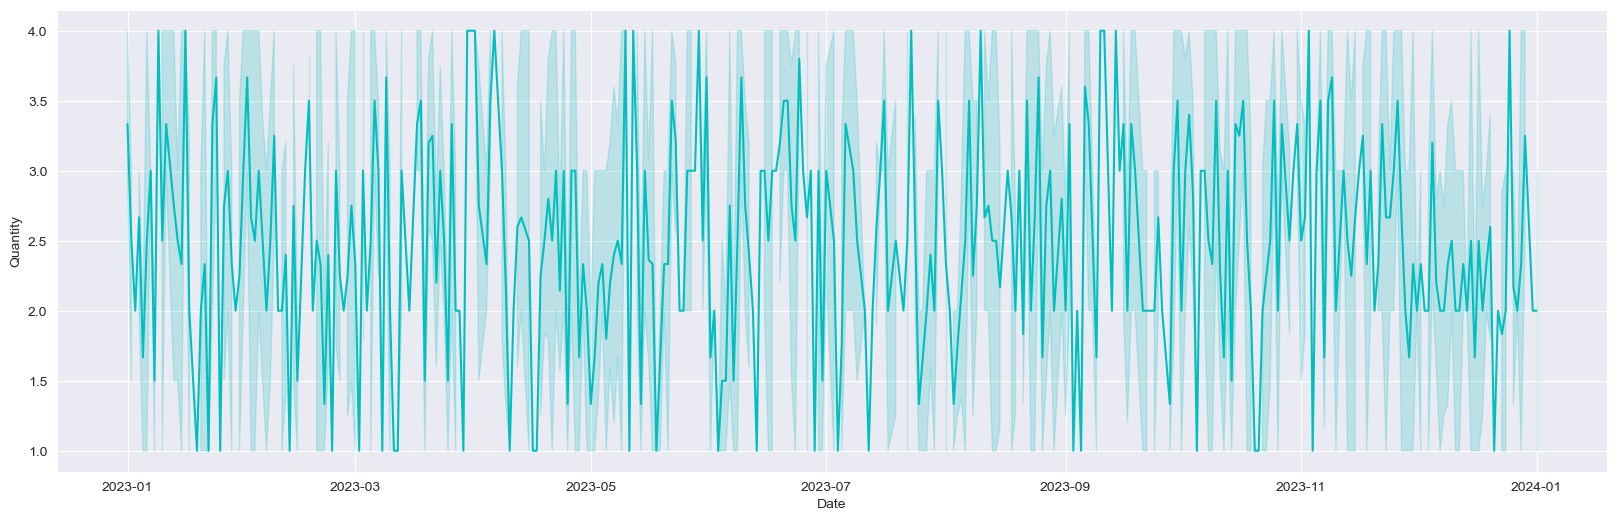

In [48]:
plt.figure(figsize=(20,6))
sns.lineplot(data=df,x=df['Date'],y=df['Quantity'],color='c')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

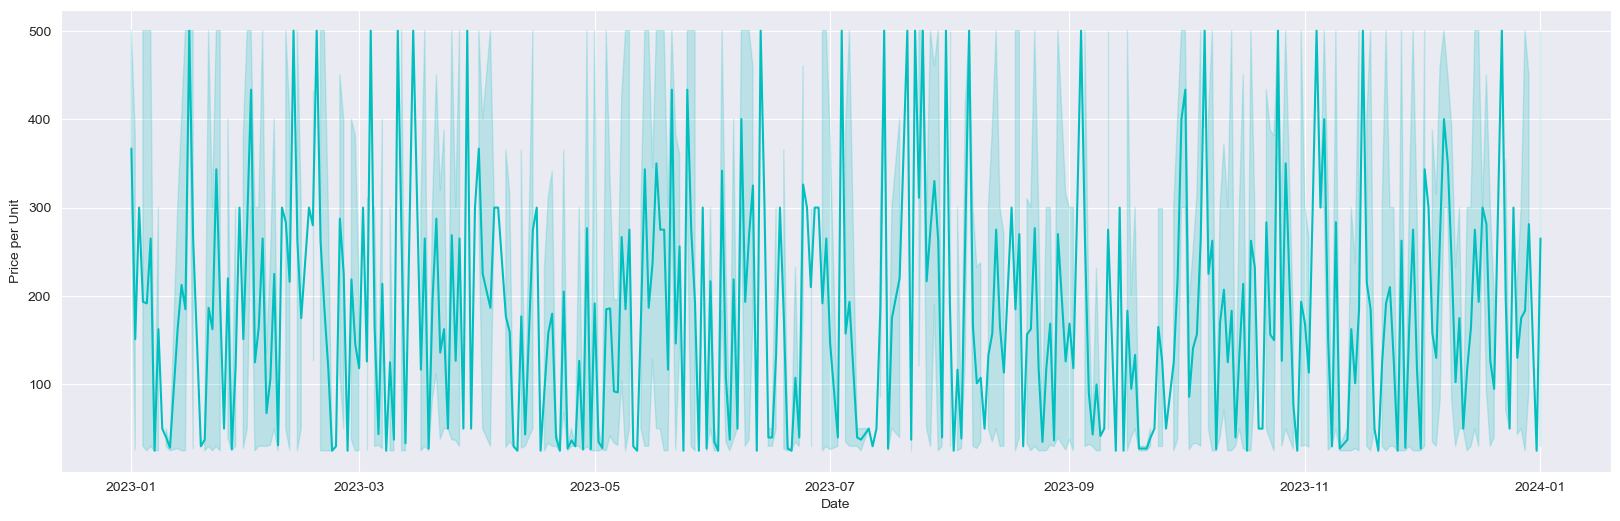

In [49]:
plt.figure(figsize=(20,6))
sns.lineplot(data=df,x=df['Date'],y=df['Price per Unit'],color='c')
plt.show

In [56]:
X=df.drop(['Date','Customer ID'],axis=1)
y=df['Total Amount']
#Split the dataset into train and test data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [57]:
#We are getting cat columns and num columns for extra encoding purpose
num_cols=[col for col in X_train.columns if X_train[col].dtype!='O']
cat_cols=[col for col in X_train.columns if X_train[col].dtype=='O']

In [59]:
#numerical processing pipeline
numeric_processor=Pipeline(
    steps=[
           ("scaler",StandardScaler())]
)

#categorical processing
from sklearn.preprocessing import OneHotEncoder
categorical_processor=Pipeline(
    steps=[
           ("onehot",OneHotEncoder(handle_unknown='ignore'))]
)

Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [60]:
numeric_processor

Pipeline(steps=[('scaler', StandardScaler())])

In [63]:
#combine technique
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(
    [('categorical',categorical_processor,['Gender','Product Category']),
     ('numerical',numeric_processor,['Age','Quantity','Price per Unit','Total Amount'])]
)

In [64]:
preprocessor

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Product Category']),
                                ('numerical',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age', 'Quantity', 'Price per Unit',
                                  'Total Amount'])])

In [65]:
from sklearn.pipeline import make_pipeline
pipe=make_pipeline(preprocessor,LinearRegression())

In [66]:
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'Product Category']),
                                                 ('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Quantity',
                                                   'Price per Unit',
                                                   'Total Amount'])])),
                ('linearregression', LinearRegression())])

In [68]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'Product Category']),
                                                 ('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Quantity',
                                                   'Price per Unit',
                                                   'Total Amount'])])),
                ('linearregression', LinearRegression())])

In [69]:
y_pred=pipe.predict(X_test)

In [70]:
from sklearn.metrics import r2_score
score=r2_score(y_pred,y_test)

In [71]:
print(score)

1.0


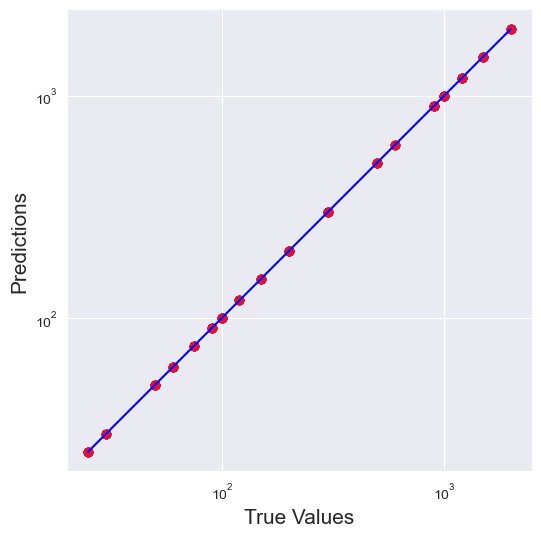

In [72]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(y_pred), max(y_test))
p2 = min(min(y_pred), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()

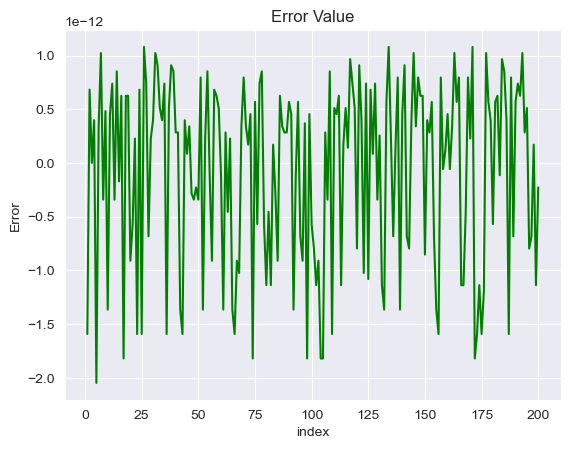

In [74]:
# plotting the error
c = [i for i in range(1,len(y_test)+1,1)]
plt.plot(c,y_test-y_pred,color='green',linestyle='-')
plt.xlabel('index')
plt.ylabel('Error')
plt.title('Error Value')
plt.show()